In [3]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, 
    roc_auc_score, roc_curve, mean_squared_error, mean_absolute_error, r2_score
)

# Set base directory and DB path
BASE_DIR = os.path.dirname(os.path.abspath(""))
DB_PATH = os.path.join(BASE_DIR, "data-package", "database", "afilearn_commerce_master.db")
SCREENSHOTS_DIR = os.path.join(BASE_DIR, "dashboards", "screenshots")
MODELS_DIR = os.path.join(BASE_DIR, "src", "models")

os.makedirs(SCREENSHOTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

In [4]:
# ==============================================================================
# STEP 1: HIGH-SIGNAL FEATURE EXTRACTION VIA SQL
# ==============================================================================
conn = sqlite3.connect(DB_PATH)

query_ml = """
SELECT 
    o.order_id,
    o.order_purchase_timestamp,
    o.is_late_delivery,
    o.delivery_delay_days,
    i.price,
    i.freight_value,
    CASE WHEN c.customer_state = s.seller_state THEN 1 ELSE 0 END AS is_same_state,
    p.product_weight_g,
    (p.product_length_cm * p.product_height_cm * p.product_width_cm) AS product_volume_cm3
FROM prod_orders_cleaned o
JOIN prod_items_cleaned i ON o.order_id = i.order_id
JOIN raw_customers c ON o.customer_id = c.customer_id
JOIN raw_sellers s ON i.seller_id = s.seller_id
JOIN raw_products p ON i.product_id = p.product_id;
"""

df_ml = pd.read_sql_query(query_ml, conn)
conn.close()

# Time features
df_ml['order_purchase_timestamp'] = pd.to_datetime(df_ml['order_purchase_timestamp'])
df_ml['purchase_hour'] = df_ml['order_purchase_timestamp'].dt.hour
df_ml['purchase_day_of_week'] = df_ml['order_purchase_timestamp'].dt.dayofweek

# # Clean nulls in product specs if any
# df_ml['product_weight_g'] = df_ml['product_weight_g'].fillna(df_ml['product_weight_g'].median())
# df_ml['product_volume_cm3'] = df_ml['product_volume_cm3'].fillna(df_ml['product_volume_cm3'].median())

# Convert product columns to numeric, coercing unparseable strings to NaN
df_ml['product_weight_g'] = pd.to_numeric(df_ml['product_weight_g'], errors='coerce')
df_ml['product_volume_cm3'] = pd.to_numeric(df_ml['product_volume_cm3'], errors='coerce')

# Impute missing values using column medians
df_ml['product_weight_g'] = df_ml['product_weight_g'].fillna(df_ml['product_weight_g'].median())
df_ml['product_volume_cm3'] = df_ml['product_volume_cm3'].fillna(df_ml['product_volume_cm3'].median())

print(f"✔ High-signal dataset loaded: {df_ml.shape[0]:,} rows | {df_ml.shape[1]} columns")

✔ High-signal dataset loaded: 110,196 rows | 11 columns



=== CLASSIFICATION EVALUATION ===
Logistic Regression ROC-AUC: 0.5612
Random Forest ROC-AUC:       0.6438

✔ Classification model and scaler saved to disk for live scoring.


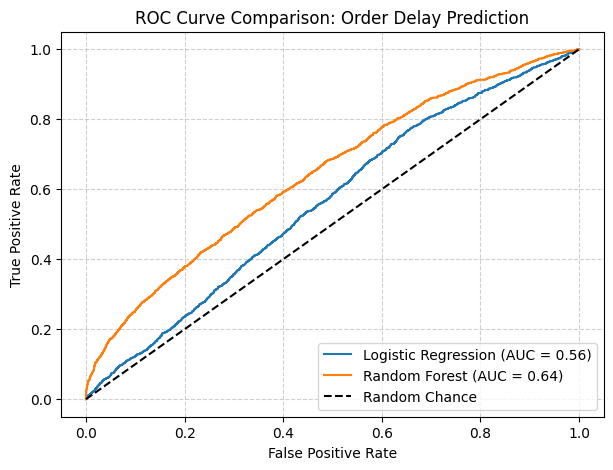

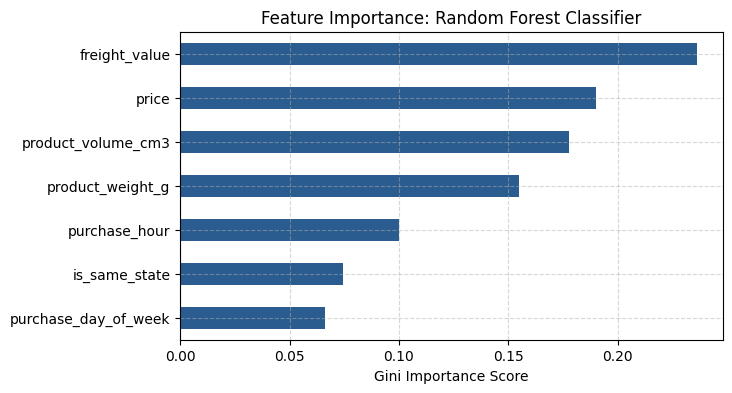

In [5]:
# ==============================================================================
# STEP 2: LATE DELIVERY CLASSIFICATION
# ==============================================================================
feature_cols = [
    'price', 'freight_value', 'is_same_state', 
    'product_weight_g', 'product_volume_cm3', 
    'purchase_hour', 'purchase_day_of_week'
]

X_cls = df_ml[feature_cols]
y_cls = df_ml['is_late_delivery']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

# Scaling for Logistic Regression
scaler = StandardScaler()
X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

# Train Classifier Models
lr_model = LogisticRegression(random_state=42, class_weight='balanced')
lr_model.fit(X_train_c_scaled, y_train_c)
y_pred_lr = lr_model.predict(X_test_c_scaled)
y_prob_lr = lr_model.predict_proba(X_test_c_scaled)[:, 1]

rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, class_weight='balanced')
rf_model.fit(X_train_c, y_train_c)
y_pred_rf = rf_model.predict(X_test_c)
y_prob_rf = rf_model.predict_proba(X_test_c)[:, 1]

# Compute ROC-AUC Scores
auc_lr = roc_auc_score(y_test_c, y_prob_lr)
auc_rf = roc_auc_score(y_test_c, y_prob_rf)

print("\n=== CLASSIFICATION EVALUATION ===")
print(f"Logistic Regression ROC-AUC: {auc_lr:.4f}")
print(f"Random Forest ROC-AUC:       {auc_rf:.4f}\n")

# Save Models & Scaler for Future Scoring/Inference
joblib.dump(rf_model, os.path.join(MODELS_DIR, "delay_classifier_rf.pkl"))
joblib.dump(scaler, os.path.join(MODELS_DIR, "feature_scaler.pkl"))
print("✔ Classification model and scaler saved to disk for live scoring.")

# --- Plot & Save ROC Curve ---
plt.figure(figsize=(7, 5))
fpr_lr, tpr_lr, _ = roc_curve(y_test_c, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test_c, y_prob_rf)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Order Delay Prediction')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig(os.path.join(SCREENSHOTS_DIR, "roc_curve_comparison.png"), bbox_inches='tight', dpi=300)
plt.show()

# --- Plot & Save Feature Importance ---
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
plt.figure(figsize=(7, 4))
importances.plot(kind='barh', color='#2b5c8f')
plt.title('Feature Importance: Random Forest Classifier')
plt.xlabel('Gini Importance Score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(os.path.join(SCREENSHOTS_DIR, "feature_importance.png"), bbox_inches='tight', dpi=300)
plt.show()

In [6]:
# ==============================================================================
# STEP 3: REGRESSION MODEL (PREDICTING DELAY DURATION IN DAYS)
# ==============================================================================
# Filter for actual delayed orders to train magnitude
df_reg = df_ml[(df_ml['is_late_delivery'] == 1) & (df_ml['delivery_delay_days'] > 0)].copy()

X_reg = df_reg[feature_cols]
y_reg = df_reg['delivery_delay_days']

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
reg_model.fit(X_tr_r, y_tr_r)
y_pred_reg = reg_model.predict(X_te_r)

print("=== REGRESSION EVALUATION (Delay Duration in Days) ===")
print(f"Mean Absolute Error (MAE):      {mean_absolute_error(y_te_r, y_pred_reg):.2f} days")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_te_r, y_pred_reg)):.2f} days")
print(f"R² Score:                       {r2_score(y_te_r, y_pred_reg):.4f}")

=== REGRESSION EVALUATION (Delay Duration in Days) ===
Mean Absolute Error (MAE):      8.19 days
Root Mean Squared Error (RMSE): 15.00 days
R² Score:                       0.0476


In [7]:
# ==============================================================================
# STEP 4: INFERENCE / SCORING SIMULATION (FUTURE/SCHEDULED ORDERS)
# ==============================================================================
print("\n=== RUNNING INFERENCE ON NEW UNFULFILLED ORDERS ===")

# Example: Simulated incoming orders scheduled for tomorrow
df_new_orders = pd.DataFrame([
    {
        'order_id': 'FUTURE_ORD_001',
        'price': 149.90,
        'freight_value': 45.20,
        'is_same_state': 0,          # Cross-state shipment
        'product_weight_g': 3500,    # Bulky item
        'product_volume_cm3': 18000,
        'purchase_hour': 14,
        'purchase_day_of_week': 0     # Monday
    },
    {
        'order_id': 'FUTURE_ORD_002',
        'price': 29.90,
        'freight_value': 12.10,
        'is_same_state': 1,          # Local same-state shipment
        'product_weight_g': 250,     # Light item
        'product_volume_cm3': 1200,
        'purchase_hour': 9,
        'purchase_day_of_week': 2     # Wednesday
    }
])

# Generate probabilities using saved model
delay_probabilities = rf_model.predict_proba(df_new_orders[feature_cols])[:, 1]

df_new_orders['predicted_delay_probability_%'] = (delay_probabilities * 100).round(2)
df_new_orders['risk_tier'] = pd.cut(
    df_new_orders['predicted_delay_probability_%'],
    bins=[-0.1, 35.0, 65.0, 100.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

print(df_new_orders[['order_id', 'is_same_state', 'product_weight_g', 'predicted_delay_probability_%', 'risk_tier']])


=== RUNNING INFERENCE ON NEW UNFULFILLED ORDERS ===
         order_id  is_same_state  product_weight_g  \
0  FUTURE_ORD_001              0              3500   
1  FUTURE_ORD_002              1               250   

   predicted_delay_probability_%    risk_tier  
0                          55.35  Medium Risk  
1                          27.15     Low Risk  


In [10]:
# ==============================================================================
# STEP 5: SCORE ALL OPEN/UNFULFILLED ORDERS & EXPORT TO SQLITE FOR POWER BI
# ==============================================================================
import sqlite3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


# Set base directory and DB path
BASE_DIR = os.path.dirname(os.path.abspath(""))
DB_PATH = os.path.join(BASE_DIR, "data-package", "database", "afilearn_commerce_master.db")
SCREENSHOTS_DIR = os.path.join(BASE_DIR, "dashboards", "screenshots")
MODELS_DIR = os.path.join(BASE_DIR, "src", "models")

print("\n--- [Step 5] Batch Scoring Open Database Orders for Power BI ---")


feature_cols = [
    'price', 'freight_value', 'is_same_state', 
    'product_weight_g', 'product_volume_cm3', 
    'purchase_hour', 'purchase_day_of_week'
]

# 1. Connect to SQLite and fetch open/pending orders
conn = sqlite3.connect(DB_PATH)

# query_open_orders = """
# SELECT 
#     o.order_id,
#     o.customer_id,
#     o.order_status,
#     o.order_purchase_timestamp,
#     i.price,
#     i.freight_value,
#     CASE WHEN c.customer_state = s.seller_state THEN 1 ELSE 0 END AS is_same_state,
#     p.product_weight_g,
#     (p.product_length_cm * p.product_height_cm * p.product_width_cm) AS product_volume_cm3
# FROM prod_orders_cleaned o
# JOIN prod_items_cleaned i ON o.order_id = i.order_id
# JOIN raw_customers c ON o.customer_id = c.customer_id
# JOIN raw_sellers s ON i.seller_id = s.seller_id
# JOIN raw_products p ON i.product_id = p.product_id;
# """

query_open_orders = """
SELECT 
    o.order_id,
    o.customer_id,
    o.order_status,
    o.order_purchase_timestamp,
    i.price,
    i.freight_value,
    CASE WHEN c.customer_state = s.seller_state THEN 1 ELSE 0 END AS is_same_state,
    p.product_weight_g,
    (p.product_length_cm * p.product_height_cm * p.product_width_cm) AS product_volume_cm3
FROM prod_orders_cleaned o
JOIN prod_items_cleaned i ON o.order_id = i.order_id
JOIN raw_customers c ON o.customer_id = c.customer_id
JOIN raw_sellers s ON i.seller_id = s.seller_id
JOIN raw_products p ON i.product_id = p.product_id
WHERE o.order_status NOT IN ('delivered', 'canceled');
"""


df_open_orders = pd.read_sql_query(query_open_orders, conn)

# 2. Preprocess features to match training schema
df_open_orders['order_purchase_timestamp'] = pd.to_datetime(df_open_orders['order_purchase_timestamp'])
df_open_orders['purchase_hour'] = df_open_orders['order_purchase_timestamp'].dt.hour
df_open_orders['purchase_day_of_week'] = df_open_orders['order_purchase_timestamp'].dt.dayofweek

df_open_orders['product_weight_g'] = pd.to_numeric(df_open_orders['product_weight_g'], errors='coerce')
df_open_orders['product_volume_cm3'] = pd.to_numeric(df_open_orders['product_volume_cm3'], errors='coerce')

df_open_orders['product_weight_g'] = df_open_orders['product_weight_g'].fillna(df_open_orders['product_weight_g'].median())
df_open_orders['product_volume_cm3'] = df_open_orders['product_volume_cm3'].fillna(df_open_orders['product_volume_cm3'].median())


# Convert ALL model feature columns to numeric
for col in feature_cols:
    df_open_orders[col] = pd.to_numeric(df_open_orders[col], errors='coerce')
    # Fill any missing values with median from training dataset
    median_val = df_open_orders[col].median() if col in df_open_orders else df_open_orders[col].median()
    df_open_orders[col] = df_open_orders[col].fillna(median_val)

# 3. Load trained Random Forest model artifact
rf_saved_model = joblib.load(os.path.join(MODELS_DIR, "delay_classifier_rf.pkl"))

# 4. Generate batch probability predictions
probabilities = rf_saved_model.predict_proba(df_open_orders[feature_cols])[:, 1]

df_open_orders['predicted_delay_probability_%'] = (probabilities * 100).round(2)
df_open_orders['risk_tier'] = pd.cut(
    df_open_orders['predicted_delay_probability_%'],
    bins=[-0.1, 35.0, 65.0, 100.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Convert timestamp and categorical columns to string for SQLite compatibility
df_open_orders['order_purchase_timestamp'] = df_open_orders['order_purchase_timestamp'].astype(str)
df_open_orders['risk_tier'] = df_open_orders['risk_tier'].astype(str)

# 5. Write predictions back to SQLite as a dedicated reporting table
df_open_orders.to_sql("fact_order_delay_predictions", conn, if_exists="replace", index=False)
conn.close()

print(f"✔ Successfully scored {len(df_open_orders):,} orders and exported to 'fact_order_delay_predictions' in SQLite.")
# Save updated dataset with predictions to CSV
df_open_orders.to_csv('../data-package/intermediate/fact_order_delay_predictions1.csv', index=False)
print("Exported 'fact_order_delay_predictions.csv' successfully!")


--- [Step 5] Batch Scoring Open Database Orders for Power BI ---


ValueError: Found array with 0 sample(s) (shape=(0, 7)) while a minimum of 1 is required by RandomForestClassifier.